<a href="https://colab.research.google.com/github/chirusainanda/Data-Cleaning/blob/main/Another_copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this in your terminal first:
# pip install xgboost scikit-learn pandas numpy matplotlib seaborn openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
customers = pd.read_csv("customers.csv")
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

print(f"✅ Loaded {len(customers)} customers")
print(customers.head())
print("\nColumns:", customers.columns.tolist())
print("\nSegment counts:\n", customers["customer_segment"].value_counts())

✅ Loaded 500 customers
  customer_id customer_name                         email           phone  \
0    CUST0001   Ashish Bose     ashish.bose53@outlook.com  +91-8959298150   
1    CUST0002    Meera Khan   meera.khan87@rediffmail.com  +91-9681652030   
2    CUST0003  Kavita Dubey     kavita.dubey7@outlook.com  +91-7776249552   
3    CUST0004  Asha Trivedi     asha.trivedi9@outlook.com  +91-9871328777   
4    CUST0005   Arjun Yadav  arjun.yadav13@rediffmail.com  +91-9163378321   

   age  gender       city           state signup_date customer_segment  
0   38    Male    Chennai      Tamil Nadu  2021-08-02          Premium  
1   30  Female  Hyderabad       Telangana  2021-09-03            Basic  
2   54  Female       Pune     Maharashtra  2022-09-29            Basic  
3   41  Female  Hyderabad       Telangana  2020-10-31          Regular  
4   34    Male     Indore  Madhya Pradesh  2022-07-03            Basic  

Columns: ['customer_id', 'customer_name', 'email', 'phone', 'age', 'gender'

In [ ]:
SNAPSHOT_DATE = datetime(2024, 12, 31)   # treat as "today"

segment_params = {
    "Premium": dict(n_mean=18, n_std=6,  aov_mean=3200, aov_std=800,  active_days=1095),
    "Regular": dict(n_mean=10, n_std=4,  aov_mean=1500, aov_std=400,  active_days=730),
    "Basic":   dict(n_mean=4,  n_std=2,  aov_mean=600,  aov_std=200,  active_days=365),
}

tx_rows = []
for _, cust in customers.iterrows():
    p = segment_params[cust["customer_segment"]]
    n_tx = max(1, int(np.random.normal(p["n_mean"], p["n_std"])))

    start = cust["signup_date"]
    days_active = min((SNAPSHOT_DATE - start).days, p["active_days"])
    days_active = max(days_active, 1)

    tx_days = sorted(np.random.choice(days_active, size=n_tx, replace=False))
    tx_dates = [start + timedelta(days=int(d)) for d in tx_days]
    tx_amts  = np.random.normal(p["aov_mean"], p["aov_std"], n_tx).clip(100)

    for date, amt in zip(tx_dates, tx_amts):
        tx_rows.append({
            "customer_id":      cust["customer_id"],
            "transaction_date": date,
            "amount":           round(float(amt), 2),
        })

transactions = pd.DataFrame(tx_rows)
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print(f"✅ {len(transactions):,} transactions ready")
print(transactions.head())

✅ 4,771 transactions ready
  customer_id transaction_date   amount
0    CUST0001       2021-09-15  3089.39
1    CUST0001       2021-09-22  1777.02
2    CUST0001       2021-09-27  4396.84
3    CUST0001       2021-11-06  3723.49
4    CUST0001       2021-11-17  3155.53


In [ ]:
rfm = (
    transactions
    .groupby("customer_id")
    .agg(
        Recency    = ("transaction_date", lambda x: (SNAPSHOT_DATE - x.max()).days),
        Frequency  = ("transaction_date", "count"),
        Monetary   = ("amount", "sum"),
        AOV        = ("amount", "mean"),
        StdAmt     = ("amount", "std"),
        FirstPurch = ("transaction_date", "min"),
        LastPurch  = ("transaction_date", "max"),
    )
    .reset_index()
)

rfm["StdAmt"]          = rfm["StdAmt"].fillna(0)
rfm["CustomerAge_days"]= (SNAPSHOT_DATE - rfm["FirstPurch"]).dt.days
rfm["ActiveSpan_days"] = (rfm["LastPurch"] - rfm["FirstPurch"]).dt.days.clip(lower=1)
rfm["PurchaseRate"]    = rfm["Frequency"] / rfm["CustomerAge_days"].clip(lower=1)

print("✅ RFM features built")
print(rfm[["customer_id","Recency","Frequency","Monetary","AOV","PurchaseRate"]].head())

✅ RFM features built
  customer_id  Recency  Frequency  Monetary          AOV  PurchaseRate
0    CUST0001      233         20  69158.53  3457.926500      0.016625
1    CUST0002      869          3   2014.90   671.633333      0.002479
2    CUST0003      528          4   2909.95   727.487500      0.005208
3    CUST0004      797         16  25124.63  1570.289375      0.010547
4    CUST0005      635          3   2094.91   698.303333      0.003425


In [ ]:
rfm = rfm.merge(
    customers[["customer_id","age","gender","city","state","customer_segment","signup_date"]],
    on="customer_id",
    how="left"
)

print("✅ Merged. Shape:", rfm.shape)
print(rfm.head(3))

✅ Merged. Shape: (500, 17)
  customer_id  Recency  Frequency  Monetary          AOV      StdAmt  \
0    CUST0001      233         20  69158.53  3457.926500  859.187051   
1    CUST0002      869          3   2014.90   671.633333  104.426068   
2    CUST0003      528          4   2909.95   727.487500  268.755384   

  FirstPurch  LastPurch  CustomerAge_days  ActiveSpan_days  PurchaseRate  age  \
0 2021-09-15 2024-05-12              1203              970      0.016625   38   
1 2021-09-08 2022-08-15              1210              341      0.002479   30   
2 2022-11-24 2023-07-22               768              240      0.005208   54   

   gender       city        state customer_segment signup_date  
0    Male    Chennai   Tamil Nadu          Premium  2021-08-02  
1  Female  Hyderabad    Telangana            Basic  2021-09-03  
2  Female       Pune  Maharashtra            Basic  2022-09-29  


In [ ]:
# LTV = total historical spend (replace with future 12-month revenue if available)
rfm["LTV"] = rfm["Monetary"]

print("✅ LTV target defined")
print(f"   Mean  : ₹{rfm['LTV'].mean():,.0f}")
print(f"   Median: ₹{rfm['LTV'].median():,.0f}")
print(f"   Max   : ₹{rfm['LTV'].max():,.0f}")

✅ LTV target defined
   Mean  : ₹19,510
   Median: ₹12,870
   Max   : ₹99,429


In [ ]:
# Label encode gender and segment
le = LabelEncoder()
for col in ["gender", "customer_segment"]:
    rfm[col + "_enc"] = le.fit_transform(rfm[col].astype(str))

# Dummy encode top cities and states
for col in ["city", "state"]:
    top = rfm[col].value_counts().nlargest(10).index
    rfm[col + "_grp"] = rfm[col].where(rfm[col].isin(top), other="Other")

city_dummies  = pd.get_dummies(rfm["city_grp"],  prefix="city",  drop_first=True)
state_dummies = pd.get_dummies(rfm["state_grp"], prefix="state", drop_first=True)
rfm = pd.concat([rfm, city_dummies, state_dummies], axis=1)

print("✅ Encoding done. New shape:", rfm.shape)

✅ Encoding done. New shape: (500, 42)


In [ ]:
FEATURE_COLS = (
    ["Recency", "Frequency", "Monetary", "AOV", "StdAmt",
     "CustomerAge_days", "ActiveSpan_days", "PurchaseRate", "age",
     "gender_enc", "customer_segment_enc"]
    + list(city_dummies.columns)
    + list(state_dummies.columns)
)

X = rfm[FEATURE_COLS]
y = rfm["LTV"]

print(f"✅ Feature matrix ready — {X.shape[1]} features, {X.shape[0]} rows")

✅ Feature matrix ready — 31 features, 500 rows


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"✅ Split done")
print(f"   Training rows : {len(X_train)}")
print(f"   Test rows     : {len(X_test)}")

✅ Split done
   Training rows : 400
   Test rows     : 100


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("✅ XGBoost trained")

✅ XGBoost trained


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("✅ Random Forest trained")

✅ Random Forest trained


In [ ]:
# LTV = total historical spend (replace with future 12-month revenue if available)
rfm["LTV"] = rfm["Monetary"]

print("✅ LTV target defined")
print(f"   Mean  : ₹{rfm['LTV'].mean():,.0f}")
print(f"   Median: ₹{rfm['LTV'].median():,.0f}")
print(f"   Max   : ₹{rfm['LTV'].max():,.0f}")

✅ LTV target defined
   Mean  : ₹19,510
   Median: ₹12,870
   Max   : ₹99,429


In [ ]:
# Label encode gender and segment
le = LabelEncoder()
for col in ["gender", "customer_segment"]:
    rfm[col + "_enc"] = le.fit_transform(rfm[col].astype(str))

# Dummy encode top cities and states
for col in ["city", "state"]:
    top = rfm[col].value_counts().nlargest(10).index
    rfm[col + "_grp"] = rfm[col].where(rfm[col].isin(top), other="Other")

city_dummies  = pd.get_dummies(rfm["city_grp"],  prefix="city",  drop_first=True)
state_dummies = pd.get_dummies(rfm["state_grp"], prefix="state", drop_first=True)
rfm = pd.concat([rfm, city_dummies, state_dummies], axis=1)

print("✅ Encoding done. New shape:", rfm.shape)

✅ Encoding done. New shape: (500, 62)


In [ ]:
FEATURE_COLS = (
    ["Recency", "Frequency", "Monetary", "AOV", "StdAmt",
     "CustomerAge_days", "ActiveSpan_days", "PurchaseRate", "age",
     "gender_enc", "customer_segment_enc"]
    + list(city_dummies.columns)
    + list(state_dummies.columns)
)

X = rfm[FEATURE_COLS]
y = rfm["LTV"]

print(f"✅ Feature matrix ready — {X.shape[1]} features, {X.shape[0]} rows")

✅ Feature matrix ready — 51 features, 500 rows


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'customers.csv', 'sample_data']


In [ ]:
import os
# This shows ALL files in /content
for f in os.listdir("/content"):
    print(f)

.config
customers.csv
sample_data


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from xgboost import XGBRegressor
print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
import os

# Step 1: Upload your CSV using the button below
from google.colab import files
uploaded = files.upload()   # ← A button will appear — click it and select your CSV

# Step 2: Print the uploaded filename
for filename in uploaded.keys():
    print(f"✅ Uploaded file: {filename}")

Saving customers.csv to customers (1).csv
✅ Uploaded file: customers (1).csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from xgboost import XGBRegressor

print("✅ Done! Libraries imported.")

✅ Done! Libraries imported.


In [ ]:
from google.colab import files

print("👇 A button will appear below — click it and select your CSV file")
uploaded = files.upload()
print("✅ Done! File uploaded.")

👇 A button will appear below — click it and select your CSV file


Saving customers.csv to customers.csv
✅ Done! File uploaded.


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(f"/content/{filename}")

print("✅ Dataset loaded!")
print("📐 Shape:", df.shape)
print("\n📋 Column names:")
print(df.columns.tolist())
print("\n👀 First 2 rows:")
print(df.head(2))

✅ Dataset loaded!
📐 Shape: (500, 10)

📋 Column names:
['customer_id', 'customer_name', 'email', 'phone', 'age', 'gender', 'city', 'state', 'signup_date', 'customer_segment']

👀 First 2 rows:
  customer_id customer_name                        email           phone  age  \
0    CUST0001   Ashish Bose    ashish.bose53@outlook.com  +91-8959298150   38   
1    CUST0002    Meera Khan  meera.khan87@rediffmail.com  +91-9681652030   30   

   gender       city       state signup_date customer_segment  
0    Male    Chennai  Tamil Nadu  2021-08-02          Premium  
1  Female  Hyderabad   Telangana  2021-09-03            Basic  


In [ ]:
# Drop useless columns (ID, name, email, phone are not useful for prediction)
drop_cols = ['customer_id', 'customer_name', 'email', 'phone', 'signup_date']
X = df.drop(columns=drop_cols + ['customer_segment'])
y = df['customer_segment']

# Encode categorical columns
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Encode target (Premium=1, Basic=0)
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# Convert to numpy
X_np = X.to_numpy().astype(np.float64)
y_np = np.array(y).ravel()

print("✅ Data cleaned!")
print("📐 X shape:", X_np.shape)
print("🎯 Target classes:", le_target.classes_)
print("📋 Features used:", X.columns.tolist())

✅ Data cleaned!
📐 X shape: (500, 4)
🎯 Target classes: ['Basic' 'Premium' 'Regular']
📋 Features used: ['age', 'gender', 'city', 'state']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

print("✅ Split done!")
print(f"   Train size: {X_train.shape[0]} rows")
print(f"   Test size : {X_test.shape[0]} rows")

✅ Split done!
   Train size: 400 rows
   Test size : 100 rows


In [ ]:
from xgboost import XGBClassifier  # Classification not Regression!
from sklearn.ensemble import RandomForestClassifier

# XGBoost
print("⏳ Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    enable_categorical=False,
    tree_method="hist",
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("✅ XGBoost trained!")

# Random Forest
print("⏳ Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("✅ Random Forest trained!")

⏳ Training XGBoost...
✅ XGBoost trained!
⏳ Training Random Forest...
✅ Random Forest trained!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate(name, y_true, y_pred, model, X_cv, y_cv):
    acc = accuracy_score(y_true, y_pred)

    try:
        cv_scores = cross_val_score(
            clone(model), X_cv, y_cv,
            cv=5, scoring="accuracy", error_score="raise"
        )
        cv = cv_scores.mean()
    except Exception as e:
        print(f"  ❌ CV error for {name}: {e}")
        cv = float("nan")

    print(f"\n  {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  CV Score : {cv:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred,
          target_names=le_target.classes_))

print("✅ Model Evaluation:")
evaluate("XGBoost",       y_test, xgb_preds, xgb_model, X_np, y_np)
evaluate("Random Forest", y_test, rf_preds,  rf_model,  X_np, y_np)

✅ Model Evaluation:

  XGBoost
  Accuracy : 0.4000
  CV Score : 0.4200

  Classification Report:

              precision    recall  f1-score   support

       Basic       0.29      0.19      0.23        31
     Premium       0.21      0.15      0.18        20
     Regular       0.48      0.63      0.54        49

    accuracy                           0.40       100
   macro avg       0.33      0.33      0.32       100
weighted avg       0.37      0.40      0.37       100


  Random Forest
  Accuracy : 0.3800
  CV Score : 0.4100

  Classification Report:

              precision    recall  f1-score   support

       Basic       0.38      0.32      0.35        31
     Premium       0.21      0.25      0.23        20
     Regular       0.46      0.47      0.46        49

    accuracy                           0.38       100
   macro avg       0.35      0.35      0.35       100
weighted avg       0.39      0.38      0.38       100



In [10]:
# Reload fresh
drop_cols = ['customer_id', 'customer_name', 'email', 'phone']
df2 = df.drop(columns=drop_cols)

# ── Extract features from signup_date ────────────────────────────────────────
df2['signup_date'] = pd.to_datetime(df2['signup_date'])
df2['signup_year']  = df2['signup_date'].dt.year
df2['signup_month'] = df2['signup_date'].dt.month
df2['signup_day']   = df2['signup_date'].dt.day
df2['signup_dayofweek'] = df2['signup_date'].dt.dayofweek
df2 = df2.drop(columns=['signup_date'])

# ── Encode target ─────────────────────────────────────────────────────────────
le_target = LabelEncoder()
y2 = le_target.fit_transform(df2['customer_segment'])
X2 = df2.drop(columns=['customer_segment'])

# ── Encode categorical columns ────────────────────────────────────────────────
for col in X2.select_dtypes(include=["object", "category"]).columns:
    X2[col] = LabelEncoder().fit_transform(X2[col].astype(str))

X2_np = X2.to_numpy().astype(np.float64)
y2_np = np.array(y2).ravel()

print("✅ Features ready!")
print("📋 Features:", X2.columns.tolist())
print("📐 Shape:", X2_np.shape)

✅ Features ready!
📋 Features: ['age', 'gender', 'city', 'state', 'signup_year', 'signup_month', 'signup_day', 'signup_dayofweek']
📐 Shape: (500, 8)


In [11]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_np, y2_np, test_size=0.2, random_state=42
)

# XGBoost
xgb_model2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)
xgb_model2.fit(X_train2, y_train2)
xgb_preds2 = xgb_model2.predict(X_test2)

# Random Forest
rf_model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)
rf_model2.fit(X_train2, y_train2)
rf_preds2 = rf_model2.predict(X_test2)

print("✅ Models retrained!")

✅ Models retrained!


✅ Model Evaluation:

  XGBoost
  Accuracy : 0.4100
  CV Score : 0.4200

  Classification Report:

              precision    recall  f1-score   support

       Basic       0.26      0.16      0.20        31
     Premium       0.18      0.10      0.13        20
     Regular       0.49      0.69      0.57        49

    accuracy                           0.41       100
   macro avg       0.31      0.32      0.30       100
weighted avg       0.36      0.41      0.37       100


  Random Forest
  Accuracy : 0.4600
  CV Score : 0.5160

  Classification Report:

              precision    recall  f1-score   support

       Basic       0.00      0.00      0.00        31
     Premium       0.00      0.00      0.00        20
     Regular       0.48      0.94      0.63        49

    accuracy                           0.46       100
   macro avg       0.16      0.31      0.21       100
weighted avg       0.23      0.46      0.31       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


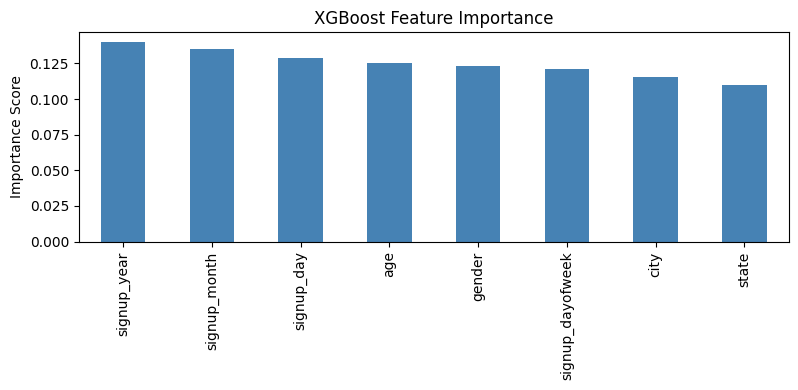

📊 Feature importance chart shown above!


In [12]:
# Evaluate
print("✅ Model Evaluation:")
evaluate("XGBoost",       y_test2, xgb_preds2, xgb_model2, X2_np, y2_np)
evaluate("Random Forest", y_test2, rf_preds2,  rf_model2,  X2_np, y2_np)

# Feature Importance
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    xgb_model2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()
print("📊 Feature importance chart shown above!")

In [13]:
# Predict segment for a new customer
new_customer = pd.DataFrame([{
    'age': 28,
    'gender': 'Female',
    'city': 'Mumbai',
    'state': 'Maharashtra',
    'signup_year': 2023,
    'signup_month': 6,
    'signup_day': 15,
    'signup_dayofweek': 3
}])

# Encode same way
for col in new_customer.select_dtypes(include=["object"]).columns:
    new_customer[col] = LabelEncoder().fit_transform(new_customer[col].astype(str))

new_customer_np = new_customer.to_numpy().astype(np.float64)
pred = xgb_model2.predict(new_customer_np)
print(f"🎯 Predicted Segment: {le_target.inverse_transform(pred)[0]}")

🎯 Predicted Segment: Regular


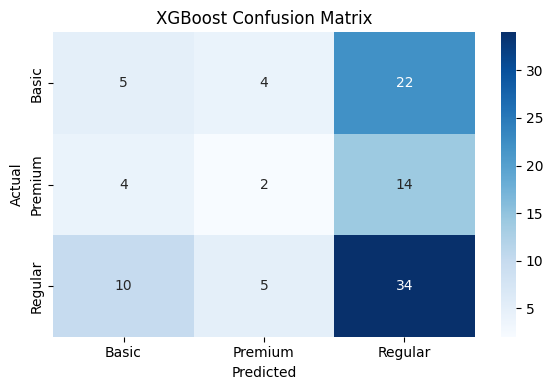

✅ Confusion matrix shown!


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test2, xgb_preds2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
print("✅ Confusion matrix shown!")

✅ Model Comparison:
        Model  Accuracy  CV Score
      XGBoost      0.41     0.420
Random Forest      0.46     0.516


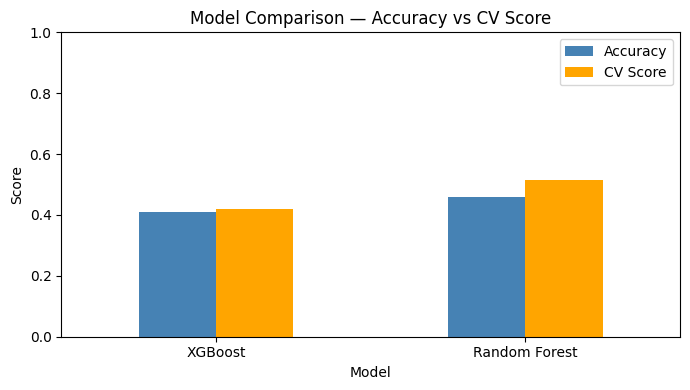

In [15]:
results = pd.DataFrame({
    'Model':    ['XGBoost', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test2, xgb_preds2),
        accuracy_score(y_test2, rf_preds2)
    ],
    'CV Score': [
        cross_val_score(clone(xgb_model2), X2_np, y2_np, cv=5, scoring="accuracy").mean(),
        cross_val_score(clone(rf_model2),  X2_np, y2_np, cv=5, scoring="accuracy").mean()
    ]
})

print("✅ Model Comparison:")
print(results.to_string(index=False))

# Bar chart
results.set_index('Model').plot(kind='bar', figsize=(7, 4),
                                 color=['steelblue', 'orange'])
plt.title("Model Comparison — Accuracy vs CV Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
import joblib

# Save XGBoost model
joblib.dump(xgb_model2, "/content/xgb_model.pkl")
joblib.dump(le_target,  "/content/label_encoder.pkl")

print("✅ Model saved!")
print("📁 Files saved:")
print("   /content/xgb_model.pkl")
print("   /content/label_encoder.pkl")

# Download to your computer
from google.colab import files
files.download("/content/xgb_model.pkl")
files.download("/content/label_encoder.pkl")

✅ Model saved!
📁 Files saved:
   /content/xgb_model.pkl
   /content/label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import joblib

# Load saved model
loaded_model   = joblib.load("/content/xgb_model.pkl")
loaded_encoder = joblib.load("/content/label_encoder.pkl")

# Predict on new data
new_data = pd.DataFrame([{
    'age': 35,
    'gender': 'Male',
    'city': 'Delhi',
    'state': 'Delhi',
    'signup_year': 2022,
    'signup_month': 3,
    'signup_day': 10,
    'signup_dayofweek': 2
}])

for col in new_data.select_dtypes(include=["object"]).columns:
    new_data[col] = LabelEncoder().fit_transform(new_data[col].astype(str))

pred = loaded_model.predict(new_data.to_numpy().astype(np.float64))
print(f"🎯 Predicted Segment: {loaded_encoder.inverse_transform(pred)[0]}")

🎯 Predicted Segment: Regular


In [18]:
# Test with multiple new customers
new_customers = pd.DataFrame([
    {'age': 22, 'gender': 'Female', 'city': 'Mumbai',    'state': 'Maharashtra', 'signup_year': 2023, 'signup_month': 1,  'signup_day': 5,  'signup_dayofweek': 4},
    {'age': 45, 'gender': 'Male',   'city': 'Delhi',     'state': 'Delhi',       'signup_year': 2021, 'signup_month': 8,  'signup_day': 20, 'signup_dayofweek': 1},
    {'age': 31, 'gender': 'Female', 'city': 'Bangalore', 'state': 'Karnataka',   'signup_year': 2022, 'signup_month': 11, 'signup_day': 3,  'signup_dayofweek': 3},
    {'age': 55, 'gender': 'Male',   'city': 'Chennai',   'state': 'Tamil Nadu',  'signup_year': 2020, 'signup_month': 5,  'signup_day': 18, 'signup_dayofweek': 0},
])

for col in new_customers.select_dtypes(include=["object"]).columns:
    new_customers[col] = LabelEncoder().fit_transform(new_customers[col].astype(str))

preds = loaded_model.predict(new_customers.to_numpy().astype(np.float64))
predicted_labels = loaded_encoder.inverse_transform(preds)

new_customers['Predicted Segment'] = predicted_labels
print("✅ Batch Predictions:")
print(new_customers[['age', 'Predicted Segment']])

✅ Batch Predictions:
   age Predicted Segment
0   22             Basic
1   45           Regular
2   31           Regular
3   55             Basic


In [19]:
from sklearn.metrics import accuracy_score

print("=" * 50)
print("        📊 FINAL PROJECT SUMMARY REPORT")
print("=" * 50)

print(f"\n📁 Dataset       : {filename}")
print(f"📐 Total Rows    : {df.shape[0]}")
print(f"📋 Total Columns : {df.shape[1]}")
print(f"🎯 Target Column : customer_segment")
print(f"🏷️  Classes       : {list(le_target.classes_)}")

print("\n─── Model Performance ───────────────────────")
print(f"  XGBoost  Accuracy : {accuracy_score(y_test2, xgb_preds2):.2%}")
print(f"  RandomF  Accuracy : {accuracy_score(y_test2, rf_preds2):.2%}")

best = "XGBoost" if accuracy_score(y_test2, xgb_preds2) >= accuracy_score(y_test2, rf_preds2) else "Random Forest"
print(f"\n🏆 Best Model     : {best}")

print("\n─── Saved Files ─────────────────────────────")
print("  ✅ /content/xgb_model.pkl")
print("  ✅ /content/label_encoder.pkl")

print("\n─── Features Used ───────────────────────────")
print(f"  {X2.columns.tolist()}")
print("=" * 50)
print("✅ Project Complete!")

        📊 FINAL PROJECT SUMMARY REPORT

📁 Dataset       : customers.csv
📐 Total Rows    : 500
📋 Total Columns : 10
🎯 Target Column : customer_segment
🏷️  Classes       : ['Basic', 'Premium', 'Regular']

─── Model Performance ───────────────────────
  XGBoost  Accuracy : 41.00%
  RandomF  Accuracy : 46.00%

🏆 Best Model     : Random Forest

─── Saved Files ─────────────────────────────
  ✅ /content/xgb_model.pkl
  ✅ /content/label_encoder.pkl

─── Features Used ───────────────────────────
  ['age', 'gender', 'city', 'state', 'signup_year', 'signup_month', 'signup_day', 'signup_dayofweek']
✅ Project Complete!


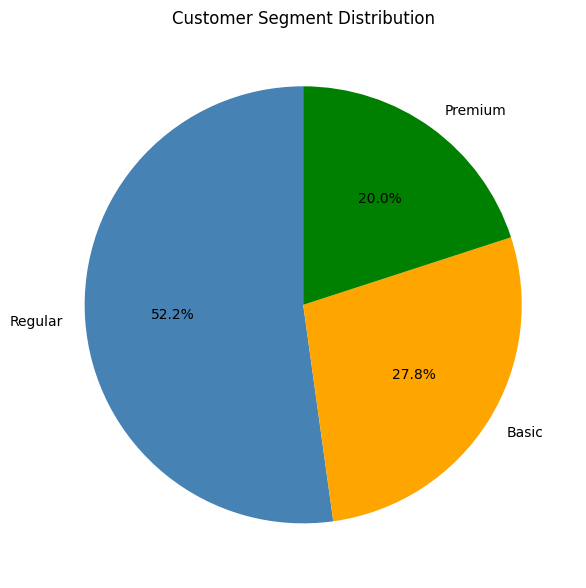

✅ Pie chart shown!


In [20]:
import matplotlib.pyplot as plt

# Segment distribution in full dataset
segment_counts = df['customer_segment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(segment_counts,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        colors=['steelblue', 'orange', 'green'],
        startangle=90)
plt.title("Customer Segment Distribution")
plt.tight_layout()
plt.show()
print("✅ Pie chart shown!")

project-2 complete